# Experiment 1: learn representations

## Preliminary

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# introduce the DKRL algorithm
import numpy as np
from tqdm import tqdm

def DKRL(y, KZ, KX, N, r, penalty, tol, T, wt = 0, verbose = 0):
    """
    Perform an double kernel representation learning.

    Parameters:
    y (numpy.ndarray): Target vector for optimization.
    KZ (numpy.ndarray): Kernel matrix Z.
    KX (numpy.ndarray): Kernel matrix X.
    N (int): Number of rows in U and V matrices.
    r (int): Number of columns in U and V matrices.
    penalty (float): Regularization parameter.
    tol (float): Tolerance for stopping criterion.
    T (int): Maximum number of iterations.
    wt (float): a number between 0 and 1 for adding identity to degenerate kernel matrix
    

    Returns:
    tuple: Final U and V matrices.
    """
    # Initialize U and V matrices randomly
    Ut = np.random.normal(loc=0, scale=1, size=(N, r))
    Vt = np.random.normal(loc=0, scale=1, size=(N, r))

    for iter in tqdm(range(T)):
        # Update U matrix
        VKX = np.repeat(np.dot(Vt.T, KX), repeats=N, axis=0)
        KZZ = np.tile(KZ, (1, r))
        DesignVt = VKX.T * KZZ  # n * (nr)
        Utt = np.linalg.solve(
            np.dot(DesignVt.T, DesignVt) + penalty * np.kron(np.eye(r, dtype=int), (1-wt) * KZ + wt * np.eye(N)),
            np.dot(DesignVt.T, y)
        )
        Utt = Utt.reshape((N, r), order="F")

        # Update V matrix
        UKZ = np.repeat(np.dot(Utt.T, KZ), repeats=N, axis=0)
        KXX = np.tile(KX, (1, r))
        DesignUt = UKZ.T * KXX  # n * (nr)
        Vtt = np.linalg.solve(
            np.dot(DesignUt.T, DesignUt) + penalty * np.kron(np.eye(r, dtype=int), (1-wt) * KX + wt * np.eye(N)),
            np.dot(DesignUt.T, y)
        )
        Vtt = Vtt.reshape((N, r), order="F")

        # Check stopping criterion
        norm_U = np.linalg.norm(Utt - Ut) / (np.linalg.norm(Ut) + 1e-3)
        norm_V = np.linalg.norm(Vtt - Vt) / (np.linalg.norm(Vt) + 1e-3)
        if verbose:
            print(f"Iteration {iter}: norm_U={norm_U}, norm_V={norm_V}")
        
        
        if norm_U < tol and norm_V < tol:
            break

        # Update Ut and Vt
        Ut = Utt
        Vt = Vtt

    y_pred = np.diag(KZ @ Utt @ Vtt.T @ KX)
    return Utt, Vtt, y_pred



In [4]:
def DKRL_pred(U, V, KZ_pred, KX_pred):
    y_pred = np.diag(KZ_pred.T @ U @ V.T @ KX_pred)
    return y_pred
    

In [5]:
def DKRL_dual(Z, X, y, r, penalty, tol, T):
    p, q, N = Z.shape[1], X.shape[1], Z.shape[0]

    Ut = np.random.normal(0, 1, (p, r))
    Vt = np.random.normal(0, 1, (q, r))
    Utt = Ut.copy()
    Vtt = Vt.copy()

    I_p = np.eye(p)
    I_q = np.eye(q)

    alpha = 1.2  # over-relaxation factor
    prev_y_pred = (Z @ Utt) * (X @ Vtt)
    y_pred_total = prev_y_pred.sum(axis=1)

    for _ in tqdm(range(int(T))):
        hhat = X @ Vtt
        ghat = Z @ Utt

        for i in range(r):
            # remove contribution of i-th component
            y_pred_i = ghat[:, i] * hhat[:, i]
            y_residual = y - (y_pred_total - y_pred_i)

            DZ = Z * hhat[:, i][:, np.newaxis]
            A = DZ.T @ DZ + penalty * I_p
            b = DZ.T @ y_residual
            update = np.linalg.solve(A, b)

            # over-relaxation
            Utt[:, i] = alpha * update + (1 - alpha) * Utt[:, i]

        # update prediction
        ghat = Z @ Utt

        for i in range(r):
            hhat = X @ Vtt
            y_pred_i = ghat[:, i] * hhat[:, i]
            y_residual = y - (ghat * hhat).sum(axis=1) + y_pred_i

            DX = X * ghat[:, i][:, np.newaxis]
            A = DX.T @ DX + penalty * I_q
            b = DX.T @ y_residual
            update = np.linalg.solve(A, b)

            # over-relaxation
            Vtt[:, i] = alpha * update + (1 - alpha) * Vtt[:, i]

        # full prediction
        ghat = Z @ Utt
        hhat = X @ Vtt
        y_pred_new = (ghat * hhat).sum(axis=1)

        # stopping criterion
        normU = np.linalg.norm(Ut)
        normV = np.linalg.norm(Vt)
        delta_U = np.linalg.norm(Utt - Ut) / (normU + 1e-4)
        delta_V = np.linalg.norm(Vtt - Vt) / (normV + 1e-3)

        if delta_U < tol and delta_V < tol:
            break

        Ut[:, :] = Utt
        Vt[:, :] = Vtt
        y_pred_total = y_pred_new

    return Utt, Vtt, y_pred_total




def DKRL_pred_dual(U, V, Z, X):
    y_pred = np.dot(Z, U) * np.dot(X, V)
    y_pred = y_pred.sum(axis=1)
    return y_pred

## Simulate CTR data

In [27]:
Z = np.load("X_news_embeddings_unique.npy")
X = np.load("X_user_features_unique.npy")

Z = Z / np.linalg.norm(Z, axis=1, keepdims=True)
X = X / np.linalg.norm(X, axis=1, keepdims=True)

# dimension of the embeddings
p = Z.shape[1]
q = X.shape[1]
N = Z.shape[0]

# population parameters
N = 5000

sampled_ind_Z = np.random.choice(range(p), size=N, replace=True)
sampled_ind_X = np.random.choice(range(q), size=N, replace=True)

Z_sampled = Z[sampled_ind_Z]
X_sampled = X[sampled_ind_X]

/var/folders/jh/3h_6szkj6jv547pqqs09_tkh0000gq/T/ipykernel_14830/484319927.py:4: RuntimeWarning: invalid value encountered in divide
  Z = Z / np.linalg.norm(Z, axis=1, keepdims=True)


In [7]:
# Simulate projection matrix
# generate random projection
r = 5

np.random.seed(2025)
P = np.random.normal(loc=0, scale=1, size=(p, q))
L, S, Rt = np.linalg.svd(P, full_matrices=False)
Lr = L[:, :r]
Rr = Rt[:r, :].T

# generate the outcome
Zr = np.dot(Z_sampled, Lr) # n*r
Xr = np.dot(X_sampled, Rr) # n*r
y = np.diag(Zr @ Xr.T) # + 0.01 * np.random.normal(loc = 0, scale = 1, size = N)
# y = (Z[:,1]**2) * (X[:,1]**2)

In [8]:
Xeval = np.random.normal(loc=1, scale=1, size=(10000, int(q)))
column_means = np.mean(np.dot(Z, Lr) @ np.dot(Xeval, Rr).T, axis=0)
sorted_indices = np.argsort(column_means)[::-1]
top_indices = sorted_indices[:10]

In [151]:
np.dot(embeddings, Lr).shape

(12387, 2)

In [70]:
np.save("./SIN-main/X.npy", X)
np.save("./SIN-main/Z.npy", Z)
np.save("./SIN-main/y.npy", y)

## Reconstruct the signals

In [22]:
# Compute the kernel
KZ = np.dot(Z_sampled, Z_sampled.T)
KX = np.dot(X_sampled, X_sampled.T)
# sigma = 0.01
# pairwise_sq_dists = np.sum(Z**2, axis=1).reshape(-1, 1) + np.sum(Z**2, axis=1) - 2 * np.dot(Z, Z.T)
# KZ = np.exp(-pairwise_sq_dists / (2 * sigma**2))
# pairwise_sq_dists = np.sum(X**2, axis=1).reshape(-1, 1) + np.sum(X**2, axis=1) - 2 * np.dot(X, X.T)
# KX = np.exp(-pairwise_sq_dists / (2 * sigma**2))

KZX = KZ * KX

# Split data into training and testing
N_train = int(0.9 * N)
N_test = int(0.1 * N)

np.random.seed(2025)
train_id = np.random.choice(range(N), size=N_train, replace=False)
test_id = np.array(list(set(range(N)) - set(train_id)))

Z_sampled_train = Z_sampled[train_id]
X_sampled_train = X_sampled[train_id]
y_train = y[train_id]

Z_sampled_test = Z_sampled[test_id]
X_sampled_test = X_sampled[test_id]
y_test = y[test_id]

# training data
KZ_train = KZ[np.ix_(train_id, train_id)]
KX_train = KX[np.ix_(train_id, train_id)]
KZX_train = KZX[np.ix_(train_id, train_id)]

# testing data
KZ_test = KZ[np.ix_(train_id, test_id)]
KX_test = KX[np.ix_(train_id, test_id)]
KZX_test = KZX[np.ix_(train_id, test_id)]

In [24]:

from sklearn.linear_model import Lasso
XZX_tr = np.hstack([Z_sampled_train, X_sampled_train]); XZX_te = np.hstack([Z_sampled_test, X_sampled_test])
y_tr = y_train; y_te = y_test
lasso = Lasso(alpha=0.01, max_iter=1000)
lasso.fit(XZX_tr, y_tr).predict(XZX_tr)

array([-0.00301388, -0.00301388, -0.00301388, ..., -0.00301388,
       -0.00301388, -0.00301388], shape=(4500,))

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
rf = RandomForestRegressor()
rf.fit(XZX_tr, y_tr).predict(XZX_tr)

array([-0.00859001, -0.01054066, -0.0144509 , ..., -0.01374276,
        0.00682938,  0.00224679], shape=(4500,))

In [26]:
fnn = MLPRegressor(hidden_layer_sizes=(100,), max_iter=500)
fnn.fit(XZX_tr, y_tr).predict(XZX_tr)

array([-0.00323618, -0.00891822, -0.0149577 , ..., -0.01691742,
        0.00182786, -0.00030678], shape=(4500,))

### Method 1: dkrl

In [11]:
# compute the kernels (simply with cosine similarity): 
penalty = 0.01
tol = 1e-4
r = 5
T = int(1e4)


In [12]:
np.random.seed(2025)
U, V, y_hat = DKRL_dual(Z_sampled_train, X_sampled_train, y_train, r=5, penalty=0.01, tol=1e-4, T=int(1e4))
y_pred = DKRL_pred_dual(U, V, Z_sampled_test, X_sampled_test)

# compute the RMSE
rmse = np.sqrt(np.mean((y_pred - y_test)**2))
print(f"RMSE: {rmse}")

 11%|█         | 1088/10000 [00:15<02:05, 70.84it/s]

RMSE: 0.0005891850366473125


In [13]:
print(np.sqrt(np.linalg.norm(y_train - y_hat)**2/N_train))
print(np.sqrt(np.linalg.norm(y_test - y_pred)**2/N_test))

0.0005110748360661442
0.0005891850366473125


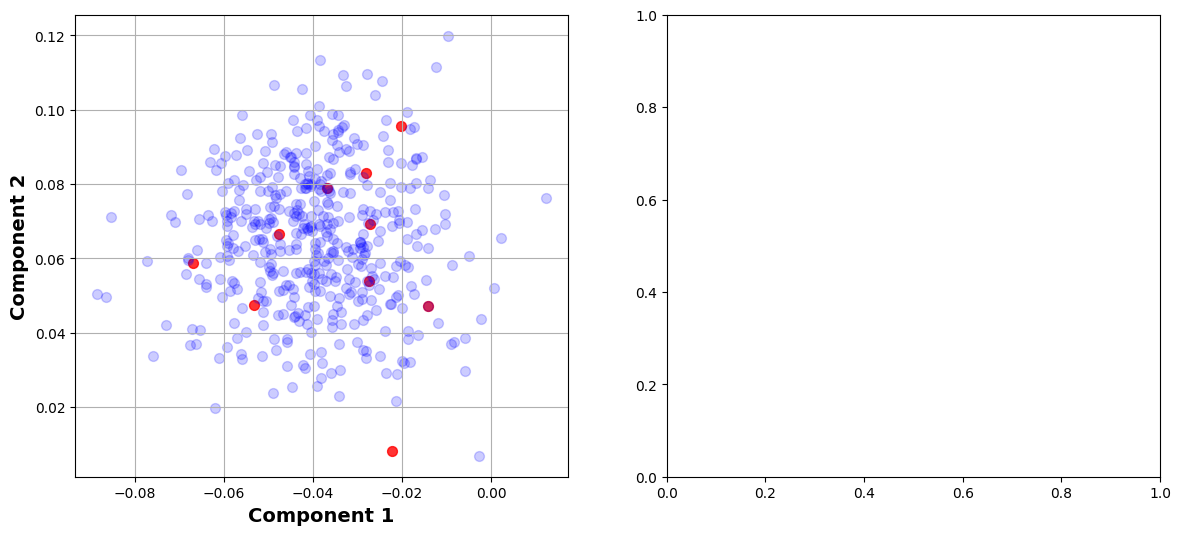

In [132]:
K_embedding = np.dot(embeddings[top_indices], Z[train_id, :].T)

Urep = K_embedding @ U
x1, y1 = Urep[:, 0], Urep[:, 1]

Ufull = KZ_train @ U
x2, y2 = Ufull[:, 0], Ufull[:, 1]
# Create figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# First subplot
axes[0].scatter(x1, y1, color='red', alpha=0.8, s=50)
axes[0].scatter(x2, y2, color='blue', alpha=0.2, s=50)
# axes[0].set_title(labels[0])
axes[0].set_xlabel("Component 1", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Component 2", fontsize=14, fontweight='bold')
axes[0].grid(True)

In [14]:
# find the representations
Urep = KZ_train @ U
Vrep = KX_train @ V
# labels=("Treatment representation", "X-representation")

# Extract x and y coordinates
x1, y1 = Urep[:, 0], Urep[:, 1]
x2, y2 = Vrep[:, 0], Vrep[:, 1]

# Create figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# First subplot
axes[0].scatter(x1, y1, color='blue', alpha=0.7, s=50)
# axes[0].set_title(labels[0])
axes[0].set_xlabel("Component 1", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Component 2", fontsize=14, fontweight='bold')
axes[0].grid(True)

# Second subplot
axes[1].scatter(x2, y2, color='red', alpha=0.7, s=50)
# axes[1].set_title(labels[1])
axes[1].set_xlabel("Component 1", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Component 2", fontsize=14, fontweight='bold')
axes[1].grid(True)

plt.savefig("Components.png")

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 100 is different from 4500)

### Method 2: RKHS regression with only treatments

In [15]:
lambda_z = 0.5e-3
alpha = np.linalg.solve(KZ_train + lambda_z * np.eye(N_train), y_train)
y_hat = KZ_train @ alpha
y_pred = KZ_test.T @ alpha

print(np.sqrt(np.linalg.norm(y_train - y_hat)**2/N_train))
print(np.sqrt(np.linalg.norm(y_test - y_pred)**2/N_test))

0.005841666264312635
0.006162789462316795


### Method 3: RKHS regression with only covariates

In [16]:
lambda_x = 1.5e-3
alpha = np.linalg.solve(KX_train + lambda_x * np.eye(N_train), y_train)
y_hat = KX_train @ alpha
y_pred = KX_test.T @ alpha

print(np.sqrt(np.linalg.norm(y_train - y_hat)**2/N_train))
print(np.sqrt(np.linalg.norm(y_test - y_pred)**2/N_test))

0.008089449427184306
0.008081102948797289


In [431]:
y_pred

array([ 0.00073719,  0.00454103,  0.0014662 , -0.00110369, -0.0009158 ,
       -0.00026172, -0.00145531,  0.00454103, -0.00099885, -0.00173622,
       -0.00034777, -0.00246217,  0.00766476,  0.00150893,  0.00042117,
       -0.00110753,  0.0017439 ,  0.00370404,  0.00197724,  0.00414537,
        0.00056074,  0.00760653,  0.00183588,  0.00414537, -0.0016039 ,
       -0.00195036,  0.00052594, -0.0015299 ,  0.00042396, -0.0001692 ,
        0.00199088, -0.00145531,  0.00529709, -0.00028121,  0.00056074,
       -0.01613913,  0.00012503,  0.00649507,  0.00051177,  0.00051289,
       -0.00176008,  0.0004183 ,  0.0059127 ,  0.00118863,  0.00303612,
        0.00376013,  0.00414537, -0.00391185,  0.00124774,  0.00015934,
        0.00454103, -0.00502333, -0.00195036, -0.00959896,  0.00117191,
        0.00705203,  0.00042396,  0.00199933,  0.00083588, -0.00211451])

### Method 4: RKHS regression with both kernels

In [21]:
lambda_x = 1.5e-4
alpha = np.linalg.solve(KZX_train + lambda_x * np.eye(N_train), y_train)
y_hat = KZX_train @ alpha
y_pred = KZX_test.T @ alpha

print(np.sqrt(np.linalg.norm(y_train - y_hat)**2/N_train))
print(np.sqrt(np.linalg.norm(y_test - y_pred)**2/N_test))

2.958276065941781e-05
6.770703841523206e-05


## Simulation runs

In [ ]:
MC = int(100)  # Monte Carlo iterations

Z = np.load("X_news_embeddings_unique.npy")
X = np.load("X_user_features_unique.npy")

Z = Z / np.linalg.norm(Z, axis=1, keepdims=True)
X = X / np.linalg.norm(X, axis=1, keepdims=True)

# dimension of the embeddings
p = Z.shape[1]
q = X.shape[1]
N = Z.shape[0]

# population parameters
N = 5000




# df = pd.read_csv("unique_headlines.csv")  # Load headlines
# headlines = np.array(df["headline"].tolist())
# embeddings = np.loadtxt('embeddings.csv', delimiter=',')
np.random.seed(2025)

# N = 500
# q = 1000
# X = np.random.normal(loc=0, scale=1, size=(1000, q))
# row_norms_X = np.linalg.norm(X, axis=1, keepdims=True)
# X = X / row_norms_X

pt_level = np.array([5e-1, 1e-1, 5e-2, 1e-2, 5e-3, 1e-3])

# Structured storage dictionary
results = {pt: {
    "DKRL": {"U": [], "V": [], "y_hat": [], "y_pred": [], "train_err": [], "test_err": []},
    "KZ": {"alpha": [], "y_hat": [], "y_pred": [], "train_err": [], "test_err": []},
    "KX": {"alpha": [], "y_hat": [], "y_pred": [], "train_err": [], "test_err": []},
    "KZX": {"alpha": [], "y_hat": [], "y_pred": [], "train_err": [], "test_err": []},
} for pt in pt_level}

for pt_iter, penalty in enumerate(pt_level):
    for iter in tqdm(range(MC), desc=f"Running MC Simulation for pt_level {penalty}"):
        # Randomly sample a subset of headlines and embeddings for evaluation
        sampled_ind_Z = np.random.choice(range(N), size=N, replace=True)
        Z_sampled = Z[sampled_ind_Z]
        sampled_ind_X = np.random.choice(range(N), size=N, replace=True)
        X_sampled = X[sampled_ind_X]

        # Simulate projection matrix
        P = np.random.normal(loc=0, scale=1, size=(p, q))
        L, S, Rt = np.linalg.svd(P, full_matrices=False)
        Lr, Rr = L[:, :r], Rt[:r, :].T

        # Generate the outcome
        Zr = np.dot(Z_sampled, Lr)
        Xr = np.dot(X_sampled, Rr)
        y = np.diag(np.dot(Zr, Xr.T))  

        # Compute the kernel
        KZ, KX = np.dot(Z_sampled, Z_sampled.T), np.dot(X_sampled, X_sampled.T)
        KZX = KZ * KX

        # Split data into training and testing
        N_train, N_test = int(0.9*N), int(0.1*N)
        train_id = np.random.choice(range(N), size=N_train, replace=False)
        test_id = np.array(list(set(range(N)) - set(train_id)))

        # Training data
        KZ_train, KX_train, KZX_train = KZ[np.ix_(train_id, train_id)], KX[np.ix_(train_id, train_id)], KZX[np.ix_(train_id, train_id)]
        y_train = y[train_id]

        # Testing data
        KZ_test, KX_test, KZX_test = KZ[np.ix_(train_id, test_id)], KX[np.ix_(train_id, test_id)], KZX[np.ix_(train_id, test_id)]
        y_test = y[test_id]

        ## **Simulation**
        # **Method 1: DKRL**
        tol, r, T = 1e-2, 2, 1000
        U, V, y_hat = DKRL(y_train, KZ_train, KX_train, N_train, r, penalty/10, tol, T, wt=0.05)
        y_pred = DKRL_pred(U, V, KZ_test, KX_test)
        train_err = np.sqrt(np.linalg.norm(y_train - y_hat)**2 / N_train)
        test_err = np.sqrt(np.linalg.norm(y_test - y_pred)**2 / N_test)

        # Store results
        results[penalty]["DKRL"]["U"].append(U)
        results[penalty]["DKRL"]["V"].append(V)
        results[penalty]["DKRL"]["y_hat"].append(y_hat)
        results[penalty]["DKRL"]["y_pred"].append(y_pred)
        results[penalty]["DKRL"]["train_err"].append(train_err)
        results[penalty]["DKRL"]["test_err"].append(test_err)

        # **Method 2: Use only KZ**
        alpha = np.linalg.solve(KZ_train + (penalty * 1e-2) * np.eye(N_train), y_train)
        y_hat, y_pred = KZ_train @ alpha, KZ_test.T @ alpha
        train_err = np.sqrt(np.linalg.norm(y_train - y_hat)**2 / N_train)
        test_err = np.sqrt(np.linalg.norm(y_test - y_pred)**2 / N_test)

        # Store results
        results[penalty]["KZ"]["alpha"].append(alpha)
        results[penalty]["KZ"]["y_hat"].append(y_hat)
        results[penalty]["KZ"]["y_pred"].append(y_pred)
        results[penalty]["KZ"]["train_err"].append(train_err)
        results[penalty]["KZ"]["test_err"].append(test_err)

        # **Method 3: Use only KX**
        alpha = np.linalg.solve(KX_train + (penalty * 1e-2) * np.eye(N_train), y_train)
        y_hat, y_pred = KX_train @ alpha, KX_test.T @ alpha
        train_err = np.sqrt(np.linalg.norm(y_train - y_hat)**2 / N_train)
        test_err = np.sqrt(np.linalg.norm(y_test - y_pred)**2 / N_test)

        # Store results
        results[penalty]["KX"]["alpha"].append(alpha)
        results[penalty]["KX"]["y_hat"].append(y_hat)
        results[penalty]["KX"]["y_pred"].append(y_pred)
        results[penalty]["KX"]["train_err"].append(train_err)
        results[penalty]["KX"]["test_err"].append(test_err)

        # **Method 4: Use both KZX**
        alpha = np.linalg.solve(KZX_train + penalty * np.eye(N_train), y_train)
        y_hat, y_pred = KZX_train @ alpha, KZX_test.T @ alpha
        train_err = np.sqrt(np.linalg.norm(y_train - y_hat)**2 / N_train)
        test_err = np.sqrt(np.linalg.norm(y_test - y_pred)**2 / N_test) 

        # Store results
        results[penalty]["KZX"]["alpha"].append(alpha)
        results[penalty]["KZX"]["y_hat"].append(y_hat)
        results[penalty]["KZX"]["y_pred"].append(y_pred)
        results[penalty]["KZX"]["train_err"].append(train_err)
        results[penalty]["KZX"]["test_err"].append(test_err)

# Save results
np.save("MC_simulation_results.npy", results)




Running MC Simulation for pt_level 0.001: 100%|██████████| 100/100 [06:41<00:00,  4.02s/it]


### A Second experiment: sensitivity regarding the choice of ranks

In [329]:
MC = int(100)  # Monte Carlo iterations
df = pd.read_csv("unique_headlines.csv")  # Load headlines
headlines = np.array(df["headline"].tolist())
embeddings = np.loadtxt('embeddings.csv', delimiter=',')
np.random.seed(2025)

r_level = np.array([2, 4, 6, 8, 10])

# Structured storage dictionary
results_rank = {r: {
    "DKRL": {"U": [], "V": [], "y_hat": [], "y_pred": [], "train_err": [], "test_err": []},
} for r in r_level}

for r_iter, r in enumerate(r_level):
    for iter in tqdm(range(MC), desc=f"Running MC Simulation for pt_level {penalty}"):
        # Randomly sample a subset of headlines and embeddings for evaluation
        ind = np.arange(len(headlines))  
        sampled_ind = np.random.choice(ind, size=N, replace=False)

        # Subsample headlines and embeddings
        headlines_sampled = headlines[sampled_ind]
        Z = embeddings[sampled_ind]

        # Dimension of embeddings
        p = len(Z[1])

        # Simulate covariate level features from Gaussian distributions
        q = 500
        X = np.random.normal(loc=0, scale=1, size=(N, q))
        X /= np.linalg.norm(X, axis=1, keepdims=True)

        # Simulate projection matrix
        P = np.random.normal(loc=0, scale=1, size=(p, q))
        L, S, Rt = np.linalg.svd(P, full_matrices=False)
        Lr, Rr = L[:, :2], Rt[:2, :].T

        # Generate the outcome
        Zr = np.dot(Z, Lr)
        Xr = np.dot(X, Rr)
        y = np.diag(np.dot(Zr, Xr.T))  

        # Compute the kernel
        KZ, KX = np.dot(Z, Z.T), np.dot(X, X.T)
        KZX = KZ * KX

        # Split data into training and testing
        N_train, N_test = 250, 50
        train_id = np.random.choice(range(N), size=N_train, replace=False)
        test_id = np.array(list(set(range(N)) - set(train_id)))

        # Training data
        KZ_train, KX_train, KZX_train = KZ[np.ix_(train_id, train_id)], KX[np.ix_(train_id, train_id)], KZX[np.ix_(train_id, train_id)]
        y_train = y[train_id]

        # Testing data
        KZ_test, KX_test, KZX_test = KZ[np.ix_(train_id, test_id)], KX[np.ix_(train_id, test_id)], KZX[np.ix_(train_id, test_id)]
        y_test = y[test_id]

        ## **Simulation**
        # **Method 1: DKRL**
        tol, T = 1e-2, 1000
        U, V, y_hat = DKRL(y_train, KZ_train, KX_train, N_train, r, penalty, tol, T, wt=0.05)
        y_pred = DKRL_pred(U, V, KZ_test, KX_test)
        train_err = np.sqrt(np.linalg.norm(y_train - y_hat)**2 / 250)
        test_err = np.sqrt(np.linalg.norm(y_test - y_pred)**2 / 50)

        # Store results
        results_rank[r]["DKRL"]["U"].append(U)
        results_rank[r]["DKRL"]["V"].append(V)
        results_rank[r]["DKRL"]["y_hat"].append(y_hat)
        results_rank[r]["DKRL"]["y_pred"].append(y_pred)
        results_rank[r]["DKRL"]["train_err"].append(train_err)
        results_rank[r]["DKRL"]["test_err"].append(test_err)

    

# Save results
np.save("MC_simulation_results_rank.npy", results_rank)

Running MC Simulation for pt_level 0.0005: 100%|██████████| 100/100 [20:18<00:00, 12.18s/it]
